# Seção 0 - Setup do ambiente e coleta do corpus

Esta seção prepara o ambiente do projeto, define a estrutura de diretórios, carrega as bibliotecas principais e realiza a coleta inicial do corpus RePro.

O objetivo desta etapa é garantir que o projeto seja reprodutível e que os dados estejam organizados antes das etapas de pré-processamento, vetorização, modelagem, extração de informação e visualização.

Nesta seção serão realizados:

1. Definição dos diretórios do projeto.
2. Verificação das bibliotecas principais.
3. Coleta do corpus.
4. Criação de uma versão bruta e uma versão intermediária dos dados.
5. Registro dos metadados da coleta.

In [1]:
from pathlib import Path
import os
import json
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd()

DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_INTERIM_DIR = BASE_DIR / "data" / "interim"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"

OUTPUT_FIGURES_DIR = BASE_DIR / "outputs" / "figures"
OUTPUT_TABLES_DIR = BASE_DIR / "outputs" / "tables"
OUTPUT_MODELS_DIR = BASE_DIR / "outputs" / "models"
OUTPUT_GRAPHS_DIR = BASE_DIR / "outputs" / "graphs"

REPORTS_DIR = BASE_DIR / "reports"

DIRS = [
    DATA_RAW_DIR,
    DATA_INTERIM_DIR,
    DATA_PROCESSED_DIR,
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
    OUTPUT_GRAPHS_DIR,
    REPORTS_DIR
]

for directory in DIRS:
    directory.mkdir(parents=True, exist_ok=True)

print("Diretório base do projeto:")
print(BASE_DIR)

print("\nDiretórios verificados/criados:")
for directory in DIRS:
    print(directory)

Diretório base do projeto:
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce

Diretórios verificados/criados:
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\raw
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\interim
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\processed
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\outputs\figures
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\outputs\tables
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\outputs\models
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\outputs\graphs
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\reports


In [2]:
import sklearn
import nltk
import spacy
import matplotlib
import networkx
import gensim
import datasets

print("Ambiente carregado com sucesso.\n")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("NLTK:", nltk.__version__)
print("spaCy:", spacy.__version__)
print("matplotlib:", matplotlib.__version__)
print("networkx:", networkx.__version__)
print("gensim:", gensim.__version__)
print("datasets:", datasets.__version__)

Ambiente carregado com sucesso.

pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.8.0
NLTK: 3.9.4
spaCy: 3.8.14
matplotlib: 3.10.9
networkx: 3.6.1
gensim: 4.4.0
datasets: 4.8.5


In [3]:
try:
    nlp_test = spacy.load("pt_core_news_sm")
    print("Modelo spaCy pt_core_news_sm carregado com sucesso.")
    print("Pipeline disponível:", nlp_test.pipe_names)
except OSError:
    print("Modelo pt_core_news_sm não encontrado.")
    print("Execute no Anaconda Prompt:")
    print("python -m spacy download pt_core_news_sm")

Modelo spaCy pt_core_news_sm carregado com sucesso.
Pipeline disponível: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']


## 0.1 Corpus escolhido

O corpus escolhido para o projeto foi o RePro — Review of Products, composto por avaliações de produtos de e-commerce em português brasileiro, adequado ao objetivo do projeto por conter textos reais de avaliações de consumidores e atributos estruturados que permitem explorar diferentes etapas de PLN, como análise textual, representação vetorial, busca por similaridade, classificação supervisionada, modelagem de tópicos, extração de entidades e construção de grafo de conhecimento.

Nesta etapa, o corpus será carregado e salvo localmente para garantir que as próximas seções do notebook utilizem os mesmos dados.

In [4]:
import os
from datasets import load_dataset

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

dataset = load_dataset("lucasnil/repro", split="train")
df = dataset.to_pandas()

print("Corpus carregado com sucesso.")
print("Dimensões do corpus:", df.shape)

display(df.head())

Corpus carregado com sucesso.
Dimensões do corpus: (10003, 22)


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,review_text,overall_rating,...,reviewer_gender,reviewer_state,topics,polarity,ENTREGA,OUTROS,PRODUTO,CONDICOESDERECEBIMENTO,INADEQUADA,ANUNCIO
0,2018-05-14 13:57:59,a4380c38e7e73687066bf66329454b33e7749a8b49ad1a...,34398895,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,NaN,Moda,Masculino,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...",3,...,M,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']",1,1,0,0,0,0
1,2018-01-18 12:02:42,fbf1d015682ddd45f97cedbc935fd42e42325498e68cd4...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...",4,...,M,ES,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0
2,2018-04-18 12:06:14,6042f06b0d63fd46499b2f6eed116df96cc8f2649df8f3...,132710805,Impressora Hp Sprocket 100 Jato de Tinta,NaN,Câmeras e Filmadoras,Impressora e Papel Fotográfico,*,"As cores da impressão não são fiéis, O custo b...",3,...,F,MG,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0
3,2018-01-23 08:11:11,4871f745136a74808a49970db18d205fd66cb666acabb2...,119882282,Livro - It: A Coisa,NaN,Livros,Literatura Estrangeira,***,"A história é muito boa, porém o autor ""enrolou...",3,...,F,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']",0,0,1,0,0,0
4,2018-02-17 11:19:38,6141e659c620ab597a5cda1b9150e180f7337434260eee...,23218825,Termometro Laser Digital Infravermelho Febre D...,NaN,Bebês,Higiene e Saúde,****,"Entrega rápida, produto muito bom Amei. Pratic...",4,...,F,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0


In [5]:
print("Colunas disponíveis no corpus:\n")

for col in df.columns:
    print("-", col)

Colunas disponíveis no corpus:

- submission_date
- reviewer_id
- product_id
- product_name
- product_brand
- site_category_lv1
- site_category_lv2
- review_title
- review_text
- overall_rating
- recommend_to_a_friend
- reviewer_birth_year
- reviewer_gender
- reviewer_state
- topics
- polarity
- ENTREGA
- OUTROS
- PRODUTO
- CONDICOESDERECEBIMENTO
- INADEQUADA
- ANUNCIO


In [6]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   submission_date         10003 non-null  str    
 1   reviewer_id             10003 non-null  str    
 2   product_id              10003 non-null  str    
 3   product_name            9997 non-null   str    
 4   product_brand           2967 non-null   str    
 5   site_category_lv1       10003 non-null  str    
 6   site_category_lv2       9708 non-null   str    
 7   review_title            10003 non-null  str    
 8   review_text             10003 non-null  str    
 9   overall_rating          10003 non-null  int64  
 10  recommend_to_a_friend   10001 non-null  str    
 11  reviewer_birth_year     9565 non-null   float64
 12  reviewer_gender         9703 non-null   str    
 13  reviewer_state          9715 non-null   str    
 14  topics                  10003 non-null  str    
 

None

In [7]:
missing_summary = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["coluna", "proporcao_valores_ausentes"]

display(missing_summary)

,coluna,proporcao_valores_ausentes
0,product_brand,0.703389
1,reviewer_birth_year,0.043787
2,reviewer_gender,0.029991
3,site_category_lv2,0.029491
4,reviewer_state,0.028791
5,product_name,0.000600
6,recommend_to_a_friend,0.000200
7,product_id,0.000000
8,submission_date,0.000000
9,reviewer_id,0.000000


## 0.2 Salvamento do corpus bruto

A versão bruta do corpus será salva em `data/raw/repro_raw.csv`, preservando os dados originais carregados da fonte, sem aplicação de limpeza textual ou transformação analítica, sendo importante para manter rastreabilidade entre os dados originais e as versões processadas nas próximas etapas.

In [8]:
raw_path = DATA_RAW_DIR / "repro_raw.csv"

df.to_csv(raw_path, index=False, encoding="utf-8")

print("Corpus bruto salvo em:")
print(raw_path)
print("Arquivo existe?", raw_path.exists())

Corpus bruto salvo em:
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\raw\repro_raw.csv
Arquivo existe? True


## 0.3 Criação da base intermediária

Nesta etapa será criada uma base intermediária com uma coluna textual unificada chamada `text_raw`, que reúne título e texto da avaliação, quando ambos estiverem disponíveis, servindo para padronizar o ponto de partida das próximas seções do pipeline.

In [9]:
df_base = df.copy()

for col in ["review_title", "review_text"]:
    if col in df_base.columns:
        df_base[col] = df_base[col].fillna("").astype(str)

if "review_title" in df_base.columns and "review_text" in df_base.columns:
    df_base["text_raw"] = (
        df_base["review_title"].str.strip()
        + ". "
        + df_base["review_text"].str.strip()
    )
elif "review_text" in df_base.columns:
    df_base["text_raw"] = df_base["review_text"].str.strip()
else:
    raise ValueError("Nenhuma coluna textual esperada foi encontrada.")

df_base["text_raw"] = (
    df_base["text_raw"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_base["doc_id"] = range(len(df_base))

display(df_base[["doc_id", "text_raw"]].head())

,doc_id,text_raw
0,0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN..."
1,1,"""compra sem susto"". Aparelho muito bom, confiá..."
2,2,"*. As cores da impressão não são fiéis, O cust..."
3,3,"***. A história é muito boa, porém o autor ""en..."
4,4,"****. Entrega rápida, produto muito bom Amei. ..."


In [10]:
possible_columns = [
    "doc_id",
    "review_title",
    "review_text",
    "text_raw",
    "overall_rating",
    "recommend_to_a_friend",
    "product_name",
    "product_brand",
    "site_category_lv1",
    "site_category_lv2",
    "reviewer_state",
    "topics",
    "polarity"
]

selected_columns = [col for col in possible_columns if col in df_base.columns]

df_base = df_base[selected_columns].copy()

print("Colunas selecionadas para a base intermediária:")
for col in df_base.columns:
    print("-", col)

print("\nDimensões da base intermediária:", df_base.shape)

display(df_base.head())

Colunas selecionadas para a base intermediária:
- doc_id
- review_title
- review_text
- text_raw
- overall_rating
- recommend_to_a_friend
- product_name
- product_brand
- site_category_lv1
- site_category_lv2
- reviewer_state
- topics
- polarity

Dimensões da base intermediária: (10003, 13)


,doc_id,review_title,review_text,text_raw,overall_rating,recommend_to_a_friend,product_name,product_brand,site_category_lv1,site_category_lv2,reviewer_state,topics,polarity
0,0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...","""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...",3,Yes,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,NaN,Moda,Masculino,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']"
1,1,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...","""compra sem susto"". Aparelho muito bom, confiá...",4,No,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,ES,['PRODUTO'],['POSITIVO']
2,2,*,"As cores da impressão não são fiéis, O custo b...","*. As cores da impressão não são fiéis, O cust...",3,No,Impressora Hp Sprocket 100 Jato de Tinta,NaN,Câmeras e Filmadoras,Impressora e Papel Fotográfico,MG,['PRODUTO'],['NEGATIVO']
3,3,***,"A história é muito boa, porém o autor ""enrolou...","***. A história é muito boa, porém o autor ""en...",3,Yes,Livro - It: A Coisa,NaN,Livros,Literatura Estrangeira,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']"
4,4,****,"Entrega rápida, produto muito bom Amei. Pratic...","****. Entrega rápida, produto muito bom Amei. ...",4,Yes,Termometro Laser Digital Infravermelho Febre D...,NaN,Bebês,Higiene e Saúde,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO']


In [11]:
df_base["text_length_chars"] = df_base["text_raw"].str.len()
df_base["text_length_words"] = df_base["text_raw"].str.split().str.len()

summary_base = {
    "n_documentos": int(df_base.shape[0]),
    "n_colunas": int(df_base.shape[1]),
    "documentos_sem_texto": int((df_base["text_raw"].str.len() == 0).sum()),
    "media_caracteres_texto": float(df_base["text_length_chars"].mean()),
    "mediana_caracteres_texto": float(df_base["text_length_chars"].median()),
    "media_palavras_texto": float(df_base["text_length_words"].mean()),
    "mediana_palavras_texto": float(df_base["text_length_words"].median())
}

summary_base

{'n_documentos': 10003,
 'n_colunas': 15,
 'documentos_sem_texto': 0,
 'media_caracteres_texto': 165.01999400179946,
 'mediana_caracteres_texto': 123.0,
 'media_palavras_texto': 27.730880735779266,
 'mediana_palavras_texto': 20.0}

In [12]:
if "polarity" in df_base.columns:
    print("Distribuição inicial da coluna polarity:")
    display(df_base["polarity"].value_counts(dropna=False).head(20))

if "topics" in df_base.columns:
    print("Distribuição inicial da coluna topics:")
    display(df_base["topics"].value_counts(dropna=False).head(20))

if "site_category_lv1" in df_base.columns:
    print("Categorias principais:")
    display(df_base["site_category_lv1"].value_counts(dropna=False).head(20))

Distribuição inicial da coluna polarity:


polarity
['POSITIVO']                4127
['NEGATIVO']                3449
['NEGATIVO', 'POSITIVO']    2018
['NEUTRO']                   409
Name: count, dtype: int64

Distribuição inicial da coluna topics:


topics
['PRODUTO']                                         4328
['ENTREGA', 'PRODUTO']                              1205
['ENTREGA', 'OUTROS']                                448
['OUTROS', 'PRODUTO']                                438
['ENTREGA']                                          402
['CONDICOESDERECEBIMENTO', 'PRODUTO']                329
['ENTREGA', 'OUTROS', 'PRODUTO']                     321
['CONDICOESDERECEBIMENTO', 'OUTROS']                 316
['ANUNCIO', 'PRODUTO']                               310
['CONDICOESDERECEBIMENTO', 'ENTREGA', 'PRODUTO']     258
['OUTROS']                                           202
['CONDICOESDERECEBIMENTO']                           194
['INADEQUADA', 'PRODUTO']                            123
['CONDICOESDERECEBIMENTO', 'OUTROS', 'PRODUTO']      120
['ANUNCIO', 'ENTREGA', 'PRODUTO']                     77
['ANUNCIO', 'OUTROS']                                 74
['ANUNCIO']                                           71
['ENTREGA', 'INADEQUADA'

Categorias principais:


site_category_lv1
Celulares e Smartphones     1526
Eletroportáteis              836
Beleza e Perfumaria          696
Utilidades Domésticas        625
Móveis                       610
Informática e Acessórios     548
TV e Home Theater            524
Brinquedos                   368
Casa e Construção            359
Automotivo                   341
Informática                  313
Eletrodomésticos             286
Cama, Mesa e Banho           266
Bebês                        258
Esporte e Lazer              240
Games                        221
Saúde                        220
Livros                       202
Moda                         193
Áudio                        144
Name: count, dtype: int64

## 0.4 Salvamento da base intermediária e dos metadados

A base intermediária será salva em `data/interim/repro_base.csv`,e também será criado um arquivo de metadados em formato JSON contendo informações básicas sobre o corpus, os arquivos gerados e as colunas selecionadas, esse registro vai facilitar a reprodutibilidade e documentará a origem dos dados utilizados no pipeline.

In [13]:
interim_path = DATA_INTERIM_DIR / "repro_base.csv"
metadata_path = DATA_INTERIM_DIR / "metadata_repro.json"

df_base.to_csv(interim_path, index=False, encoding="utf-8")

metadata = {
    "nome_corpus": "RePro - Review of Products",
    "descricao": "Corpus de avaliações de produtos de e-commerce em português brasileiro, anotado com sentimento e tópicos.",
    "dataset_huggingface": "lucasnil/repro",
    "arquivo_raw": str(raw_path.relative_to(BASE_DIR)),
    "arquivo_intermediario": str(interim_path.relative_to(BASE_DIR)),
    "n_documentos": int(df_base.shape[0]),
    "n_colunas": int(df_base.shape[1]),
    "colunas_utilizadas": list(df_base.columns)
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Base intermediária salva em:", interim_path)
print("Metadados salvos em:", metadata_path)

Base intermediária salva em: C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\interim\repro_base.csv
Metadados salvos em: C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\interim\metadata_repro.json


In [14]:
print("Conferência dos arquivos criados:\n")

for path in [raw_path, interim_path, metadata_path]:
    print(path.relative_to(BASE_DIR), "->", path.exists())

print("\nAmostra final da base intermediária:")
display(df_base.sample(5, random_state=42))

Conferência dos arquivos criados:

data\raw\repro_raw.csv -> True
data\interim\repro_base.csv -> True
data\interim\metadata_repro.json -> True

Amostra final da base intermediária:


,doc_id,review_title,review_text,text_raw,overall_rating,recommend_to_a_friend,product_name,product_brand,site_category_lv1,site_category_lv2,reviewer_state,topics,polarity,text_length_chars,text_length_words
6883,6883,PÉSSIMO,"Diferente da foto, nem se parece um tapete, me...","PÉSSIMO. Diferente da foto, nem se parece um t...",1,No,Tapete Jumper Chevron Blue Retangular (150x200...,corttex casa,"Cama, Mesa e Banho",Tapetes,NaN,"['ANUNCIO', 'PRODUTO']",['NEGATIVO'],68,11
5836,5836,PRODUTO EXCELENTE,"Produto de alta qualidade, som e imagem perfei...","PRODUTO EXCELENTE. Produto de alta qualidade, ...",5,Yes,Smart TV LED 32'' Semp Toshiba TCL 32L2600 HD ...,NaN,TV e Home Theater,TV,CE,"['ENTREGA', 'PRODUTO']",['POSITIVO'],85,12
8601,8601,gostei bastante,"muito bem feito, ele é todo de borracha, e tec...","gostei bastante. muito bem feito, ele é todo d...",5,Yes,Tênis Infantil Masculino Homem Aranha Grendene...,NaN,Moda,Infantil,RJ,['PRODUTO'],['POSITIVO'],142,25
2545,2545,Esse produto não é ajustável,Comprei esse patins para minha filha justament...,Esse produto não é ajustável. Comprei esse pat...,2,No,Patins Infantil 4 Rodas Quad Ajustável Winmax ...,NaN,Brinquedos,Patins Infantil,NaN,['PRODUTO'],['NEGATIVO'],185,30
8697,8697,insatisfeito com a compra,Não posso avaliar um produto que comprei no di...,insatisfeito com a compra. Não posso avaliar u...,1,No,Tênis Fly Rainha,NaN,Vestuário Esportivo,Feminino,PI,['ENTREGA'],['NEGATIVO'],199,37


## 0.5 Síntese da Seção 0

Nesta seção, o ambiente do projeto foi preparado, os diretórios foram organizados e o corpus RePro foi coletado e salvo localmente.

Foram criadas duas versões dos dados:

- `data/raw/repro_raw.csv`: versão bruta do corpus;
- `data/interim/repro_base.csv`: versão intermediária com coluna textual unificada `text_raw`.

Também foi gerado o arquivo `data/interim/metadata_repro.json`, contendo metadados da coleta e da estrutura da base.

# Seção 1 - Pré-processamento textual com NLTK e spaCy

Esta seção implementa o pipeline de pré-processamento textual aplicado ao corpus RePro.

O objetivo é transformar os textos brutos das avaliações em versões mais adequadas para análise linguística e modelagem, preservando o significado dos textos e reduzindo ruídos comuns em avaliações de e-commerce.

As etapas realizadas nesta seção são:

1. Carregamento da base intermediária.
2. Inspeção inicial do corpus.
3. Tokenização de sentenças e palavras com NLTK.
4. Normalização textual.
5. Remoção de stopwords padrão e customizadas.
6. Comparação entre stemming e lemmatização.
7. POS tagging com spaCy.
8. Análise do impacto do pré-processamento no vocabulário.
9. Visualizações de apoio.

## 1.1 Carregamento da base intermediária

A base utilizada nesta seção é `data/interim/repro_base.csv`, que contém a coluna `text_raw`, que reúne o título e o corpo de cada avaliação. A partir dela serão criadas novas colunas processadas para uso nas próximas etapas do projeto.

In [15]:
from pathlib import Path
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

BASE_DIR = Path.cwd()

DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_INTERIM_DIR = BASE_DIR / "data" / "interim"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"

OUTPUT_FIGURES_DIR = BASE_DIR / "outputs" / "figures"
OUTPUT_TABLES_DIR = BASE_DIR / "outputs" / "tables"

for directory in [DATA_PROCESSED_DIR, OUTPUT_FIGURES_DIR, OUTPUT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

base_path = DATA_INTERIM_DIR / "repro_base.csv"

df = pd.read_csv(base_path)

print("Base carregada com sucesso.")
print("Dimensões:", df.shape)

display(df.head())

Base carregada com sucesso.
Dimensões: (10003, 15)


,doc_id,review_title,review_text,text_raw,overall_rating,recommend_to_a_friend,product_name,product_brand,site_category_lv1,site_category_lv2,reviewer_state,topics,polarity,text_length_chars,text_length_words
0,0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...","""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...",3,Yes,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,NaN,Moda,Masculino,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']",580,97
1,1,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...","""compra sem susto"". Aparelho muito bom, confiá...",4,No,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,ES,['PRODUTO'],['POSITIVO'],117,20
2,2,*,"As cores da impressão não são fiéis, O custo b...","*. As cores da impressão não são fiéis, O cust...",3,No,Impressora Hp Sprocket 100 Jato de Tinta,NaN,Câmeras e Filmadoras,Impressora e Papel Fotográfico,MG,['PRODUTO'],['NEGATIVO'],73,15
3,3,***,"A história é muito boa, porém o autor ""enrolou...","***. A história é muito boa, porém o autor ""en...",3,Yes,Livro - It: A Coisa,NaN,Livros,Literatura Estrangeira,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']",79,16
4,4,****,"Entrega rápida, produto muito bom Amei. Pratic...","****. Entrega rápida, produto muito bom Amei. ...",4,Yes,Termometro Laser Digital Infravermelho Febre D...,NaN,Bebês,Higiene e Saúde,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],57,8


In [16]:
print("Colunas disponíveis:")
for col in df.columns:
    print("-", col)

print("\nInformações gerais:")
df.info()

Colunas disponíveis:
- doc_id
- review_title
- review_text
- text_raw
- overall_rating
- recommend_to_a_friend
- product_name
- product_brand
- site_category_lv1
- site_category_lv2
- reviewer_state
- topics
- polarity
- text_length_chars
- text_length_words

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   doc_id                 10003 non-null  int64
 1   review_title           10003 non-null  str  
 2   review_text            10003 non-null  str  
 3   text_raw               10003 non-null  str  
 4   overall_rating         10003 non-null  int64
 5   recommend_to_a_friend  10001 non-null  str  
 6   product_name           9997 non-null   str  
 7   product_brand          2967 non-null   str  
 8   site_category_lv1      10003 non-null  str  
 9   site_category_lv2      9708 non-null   str  
 10  reviewer_state   

In [17]:
text_summary = pd.DataFrame({
    "métrica": [
        "quantidade_documentos",
        "documentos_sem_texto",
        "média_caracteres",
        "mediana_caracteres",
        "média_palavras",
        "mediana_palavras"
    ],
    "valor": [
        len(df),
        int((df["text_raw"].fillna("").str.len() == 0).sum()),
        round(df["text_raw"].fillna("").str.len().mean(), 2),
        round(df["text_raw"].fillna("").str.len().median(), 2),
        round(df["text_raw"].fillna("").str.split().str.len().mean(), 2),
        round(df["text_raw"].fillna("").str.split().str.len().median(), 2)
    ]
})

display(text_summary)

text_summary.to_csv(
    OUTPUT_TABLES_DIR / "section_1_text_initial_summary.csv",
    index=False,
    encoding="utf-8"
)

,métrica,valor
0,quantidade_documentos,10003.00
1,documentos_sem_texto,0.00
2,média_caracteres,165.02
3,mediana_caracteres,123.00
4,média_palavras,27.73
5,mediana_palavras,20.00


## 1.2 Tokenização de sentenças e palavras

A tokenização é a etapa que divide o texto em unidades menores. Neste projeto são usadas duas formas:

- tokenização de sentenças, para estimar a estrutura dos documentos;
- tokenização de palavras, para preparar o vocabulário usado nas próximas etapas.

A tokenização será feita com NLTK, utilizando recursos compatíveis com textos em português.

In [18]:
import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("rslp", quiet=True)

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

In [19]:
def tokenize_sentences_pt(text):
    text = "" if pd.isna(text) else str(text)
    return sent_tokenize(text, language="portuguese")

def tokenize_words_pt(text):
    text = "" if pd.isna(text) else str(text)
    return word_tokenize(text, language="portuguese")

df["sentences_raw"] = df["text_raw"].apply(tokenize_sentences_pt)
df["tokens_raw"] = df["text_raw"].apply(tokenize_words_pt)

df["n_sentences"] = df["sentences_raw"].apply(len)
df["n_tokens_raw"] = df["tokens_raw"].apply(len)

display(df[["doc_id", "text_raw", "sentences_raw", "tokens_raw", "n_sentences", "n_tokens_raw"]].head(3))

,doc_id,text_raw,sentences_raw,tokens_raw,n_sentences,n_tokens_raw
0,0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","[""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICA...","[``, O, PRODUTO, QUE, NÃO, ESTÁ, AGRADANDO, É,...",10,122
1,1,"""compra sem susto"". Aparelho muito bom, confiá...","[""compra sem susto""., Aparelho muito bom, conf...","[``, compra, sem, susto, '', ., Aparelho, muit...",2,27
2,2,"*. As cores da impressão não são fiéis, O cust...","[*., As cores da impressão não são fiéis, O cu...","[*, ., As, cores, da, impressão, não, são, fié...",2,17


## 1.3 Normalização textual

A normalização textual reduz variações superficiais do texto. Nesta etapa são aplicadas as seguintes transformações:

- conversão para letras minúsculas;
- remoção de URLs;
- remoção de e-mails;
- remoção de caracteres que não são letras;
- redução de espaços duplicados.

Os acentos foram preservados porque o corpus está em português e a preservação de acentuação ajuda a manter a qualidade linguística da lemmatização com spaCy.

In [20]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text_raw"].apply(normalize_text)
df["tokens_norm"] = df["text_norm"].apply(tokenize_words_pt)
df["n_tokens_norm"] = df["tokens_norm"].apply(len)

display(df[["text_raw", "text_norm", "tokens_norm"]].head(5))

,text_raw,text_norm,tokens_norm
0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...",o produto que não está agradando é a americana...,"[o, produto, que, não, está, agradando, é, a, ..."
1,"""compra sem susto"". Aparelho muito bom, confiá...",compra sem susto aparelho muito bom confiável ...,"[compra, sem, susto, aparelho, muito, bom, con..."
2,"*. As cores da impressão não são fiéis, O cust...",as cores da impressão não são fiéis o custo be...,"[as, cores, da, impressão, não, são, fiéis, o,..."
3,"***. A história é muito boa, porém o autor ""en...",a história é muito boa porém o autor enrolou u...,"[a, história, é, muito, boa, porém, o, autor, ..."
4,"****. Entrega rápida, produto muito bom Amei. ...",entrega rápida produto muito bom amei praticidade,"[entrega, rápida, produto, muito, bom, amei, p..."


## 1.4 Remoção de stopwords

Stopwords são palavras muito frequentes que geralmente carregam pouco conteúdo semântico isoladamente, como artigos, preposições e pronomes. Além da lista padrão de stopwords em português do NLTK, foram adicionadas stopwords customizadas comuns em avaliações informais, como abreviações e marcas de oralidade.

Termos centrais do domínio, como `produto`, `entrega`, `preço`, `marca` e `loja`, foram preservados neste momento, pois podem ser importantes para a análise de tópicos, classificação e construção do grafo de conhecimento.

In [21]:
stopwords_pt = set(stopwords.words("portuguese"))

custom_stopwords = {
    "pra", "pro", "pros", "pras",
    "vc", "vcs", "voce", "voçê",
    "ta", "tá", "ne", "né",
    "ai", "aí", "q", "pq",
    "tb", "tambem", "também"
}

stopwords_final = stopwords_pt.union(custom_stopwords)

def remove_stopwords_tokens(tokens):
    clean_tokens = []
    for token in tokens:
        token = token.lower().strip()
        if token.isalpha() and token not in stopwords_final and len(token) > 2:
            clean_tokens.append(token)
    return clean_tokens

df["tokens_no_stop"] = df["tokens_norm"].apply(remove_stopwords_tokens)
df["text_no_stop"] = df["tokens_no_stop"].apply(lambda tokens: " ".join(tokens))

display(df[["text_norm", "tokens_no_stop", "text_no_stop"]].head(5))

,text_norm,tokens_no_stop,text_no_stop
0,o produto que não está agradando é a americana...,"[produto, agradando, americanas, produto, pode...",produto agradando americanas produto pode bom ...
1,compra sem susto aparelho muito bom confiável ...,"[compra, susto, aparelho, bom, confiável, valo...",compra susto aparelho bom confiável valor aqui...
2,as cores da impressão não são fiéis o custo be...,"[cores, impressão, fiéis, custo, benefício, va...",cores impressão fiéis custo benefício vale pena
3,a história é muito boa porém o autor enrolou u...,"[história, boa, porém, autor, enrolou, pouco, ...",história boa porém autor enrolou pouco meio livro
4,entrega rápida produto muito bom amei praticidade,"[entrega, rápida, produto, bom, amei, praticid...",entrega rápida produto bom amei praticidade


## 1.5 Comparação entre stemming e lemmatização

Stemming e lemmatização são técnicas para reduzir variações de palavras. O stemming reduz palavras a radicais aproximados, em português, isso pode reduzir bastante o vocabulário, mas frequentemente gera formas pouco interpretáveis. Já a lemmatização reduz palavras ao seu lema, preservando melhor a forma linguística. Por isso, tende a ser mais adequada quando a interpretação dos termos é importante, como neste projeto.

In [22]:
stemmer = RSLPStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(token) for token in tokens]

df["tokens_stem"] = df["tokens_no_stop"].apply(apply_stemming)
df["text_stem"] = df["tokens_stem"].apply(lambda tokens: " ".join(tokens))

display(df[["tokens_no_stop", "tokens_stem", "text_stem"]].head(5))

,tokens_no_stop,tokens_stem,text_stem
0,"[produto, agradando, americanas, produto, pode...","[produt, agrad, americ, produt, pod, bom, poré...",produt agrad americ produt pod bom porém ameri...
1,"[compra, susto, aparelho, bom, confiável, valo...","[compr, sust, aparelh, bom, confi, val, aquisi...",compr sust aparelh bom confi val aquisi cont t...
2,"[cores, impressão, fiéis, custo, benefício, va...","[cor, impress, fiel, cust, benefíci, val, pen]",cor impress fiel cust benefíci val pen
3,"[história, boa, porém, autor, enrolou, pouco, ...","[histór, boa, porém, autor, enrol, pouc, mei, ...",histór boa porém autor enrol pouc mei livr
4,"[entrega, rápida, produto, bom, amei, praticid...","[entreg, rápid, produt, bom, ame, pratic]",entreg rápid produt bom ame pratic


## 1.6 Lemmatização e POS tagging com spaCy

Nesta etapa, o spaCy é usado para duas tarefas:

- lemmatização dos tokens;
- identificação da classe gramatical dos termos, conhecida como POS tagging.

O POS tagging ajuda a caracterizar linguisticamente o corpus, permitindo observar se as avaliações são compostas principalmente por substantivos, adjetivos, verbos ou outras classes. Em avaliações de produtos, substantivos e adjetivos tendem a ser especialmente relevantes, pois indicam objetos avaliados e qualificações atribuídas pelos consumidores.

In [23]:
import spacy

nlp = spacy.load("pt_core_news_sm")

print("Modelo spaCy carregado.")
print("Pipeline:", nlp.pipe_names)

Modelo spaCy carregado.
Pipeline: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']


In [24]:
lemma_tokens_by_doc = []
pos_records = []

texts = df["text_norm"].fillna("").tolist()
doc_ids = df["doc_id"].tolist()

for doc_id, doc in zip(doc_ids, nlp.pipe(texts, batch_size=128, n_process=1)):
    lemmas = []
    
    for token in doc:
        lemma = token.lemma_.lower().strip()
        
        if (
            token.is_alpha
            and lemma not in stopwords_final
            and len(lemma) > 2
        ):
            lemmas.append(lemma)
            
            pos_records.append({
                "doc_id": doc_id,
                "token": token.text.lower(),
                "lemma": lemma,
                "pos": token.pos_
            })
    
    lemma_tokens_by_doc.append(lemmas)

df["tokens_lemma"] = lemma_tokens_by_doc
df["text_lemma"] = df["tokens_lemma"].apply(lambda tokens: " ".join(tokens))

pos_df = pd.DataFrame(pos_records)

display(df[["text_norm", "tokens_lemma", "text_lemma"]].head(5))
display(pos_df.head())

,text_norm,tokens_lemma,text_lemma
0,o produto que não está agradando é a americana...,"[produto, agradar, americana, produto, poder, ...",produto agradar americana produto poder bom po...
1,compra sem susto aparelho muito bom confiável ...,"[compra, susto, aparelho, bom, confiável, valo...",compra susto aparelho bom confiável valor aqui...
2,as cores da impressão não são fiéis o custo be...,"[cor, de o, impressão, fiel, custo, benefício,...",cor de o impressão fiel custo benefício valer ...
3,a história é muito boa porém o autor enrolou u...,"[história, bom, porém, autor, enrolar, pouco, ...",história bom porém autor enrolar pouco em o me...
4,entrega rápida produto muito bom amei praticidade,"[entregar, rápidar, produto, bom, amei, pratic...",entregar rápidar produto bom amei praticidade


,doc_id,token,lemma,pos
0,0,produto,produto,NOUN
1,0,agradando,agradar,VERB
2,0,americanas,americana,NOUN
3,0,produto,produto,NOUN
4,0,pode,poder,VERB


In [25]:
pos_counts = (
    pos_df["pos"]
    .value_counts()
    .reset_index()
)

pos_counts.columns = ["pos", "frequencia"]

display(pos_counts)

pos_counts.to_csv(
    OUTPUT_TABLES_DIR / "section_1_pos_distribution.csv",
    index=False,
    encoding="utf-8"
)

,pos,frequencia
0,NOUN,62442
1,VERB,46527
2,ADJ,27229
3,ADP,13342
4,ADV,10574
5,DET,2669
6,PRON,2513
7,PROPN,1701
8,SCONJ,1264
9,AUX,758


## 1.7 Impacto do pré-processamento no vocabulário

Para avaliar o impacto das decisões de pré-processamento, serão comparados os tamanhos de vocabulário em quatro versões:

1. tokens normalizados;
2. tokens sem stopwords;
3. tokens com stemming;
4. tokens com lemmatização.

Essa comparação permite verificar quanto cada etapa reduz o vocabulário e qual estratégia preserva melhor a interpretabilidade dos termos.

In [26]:
def calculate_vocab_stats(token_series, label):
    total_tokens = sum(len(tokens) for tokens in token_series)
    vocab = set(token for tokens in token_series for token in tokens)
    
    return {
        "representacao": label,
        "total_tokens": total_tokens,
        "tamanho_vocabulario": len(vocab),
        "media_tokens_por_documento": round(total_tokens / len(token_series), 2)
    }

vocab_stats = pd.DataFrame([
    calculate_vocab_stats(df["tokens_norm"], "tokens_normalizados"),
    calculate_vocab_stats(df["tokens_no_stop"], "sem_stopwords"),
    calculate_vocab_stats(df["tokens_stem"], "stemming"),
    calculate_vocab_stats(df["tokens_lemma"], "lemmatizacao")
])

display(vocab_stats)

vocab_stats.to_csv(
    OUTPUT_TABLES_DIR / "section_1_vocab_impact.csv",
    index=False,
    encoding="utf-8"
)

,representacao,total_tokens,tamanho_vocabulario,media_tokens_por_documento
0,tokens_normalizados,274716,14413,27.46
1,sem_stopwords,156696,13999,15.66
2,stemming,156696,7142,15.66
3,lemmatizacao,170341,10881,17.03


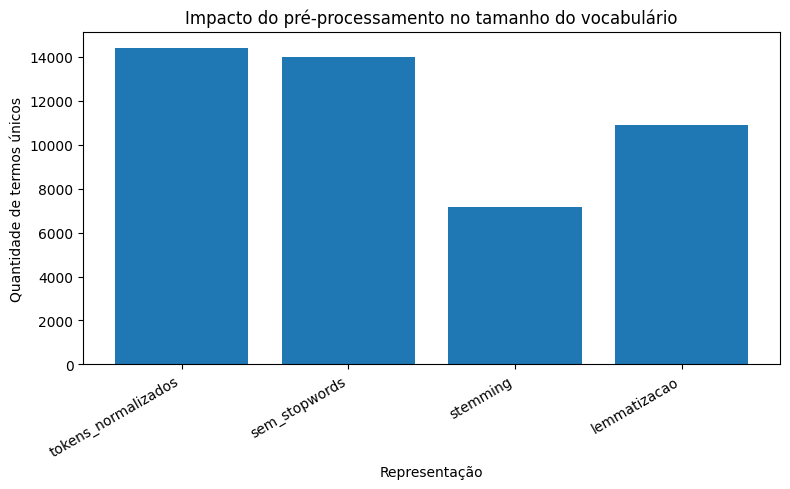

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(vocab_stats["representacao"], vocab_stats["tamanho_vocabulario"])
plt.title("Impacto do pré-processamento no tamanho do vocabulário")
plt.xlabel("Representação")
plt.ylabel("Quantidade de termos únicos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "section_1_vocab_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.8 Visualizações do pré-processamento

Nesta etapa são geradas visualizações para apoiar a interpretação do corpus e das decisões de pré-processamento:

- histograma de comprimento dos documentos;
- distribuição dos termos mais frequentes;
- distribuição de classes gramaticais;
- nuvem de palavras com os termos lematizados.

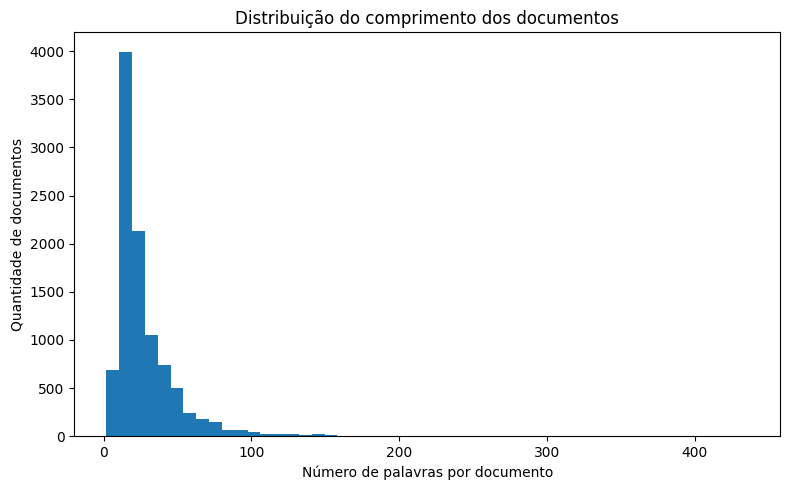

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["text_length_words"], bins=50)
plt.title("Distribuição do comprimento dos documentos")
plt.xlabel("Número de palavras por documento")
plt.ylabel("Quantidade de documentos")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "section_1_document_length_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
term_counter = Counter()

for tokens in df["tokens_lemma"]:
    term_counter.update(tokens)

top_terms = pd.DataFrame(
    term_counter.most_common(30),
    columns=["termo", "frequencia"]
)

display(top_terms)

top_terms.to_csv(
    OUTPUT_TABLES_DIR / "section_1_top_terms_lemma.csv",
    index=False,
    encoding="utf-8"
)

,termo,frequencia
0,produto,8174
1,de o,6730
2,bom,5509
3,em o,4004
4,ter,2885
5,gostar,2050
6,vir,1526
7,chegar,1505
8,qualidade,1449
9,entrega,1329


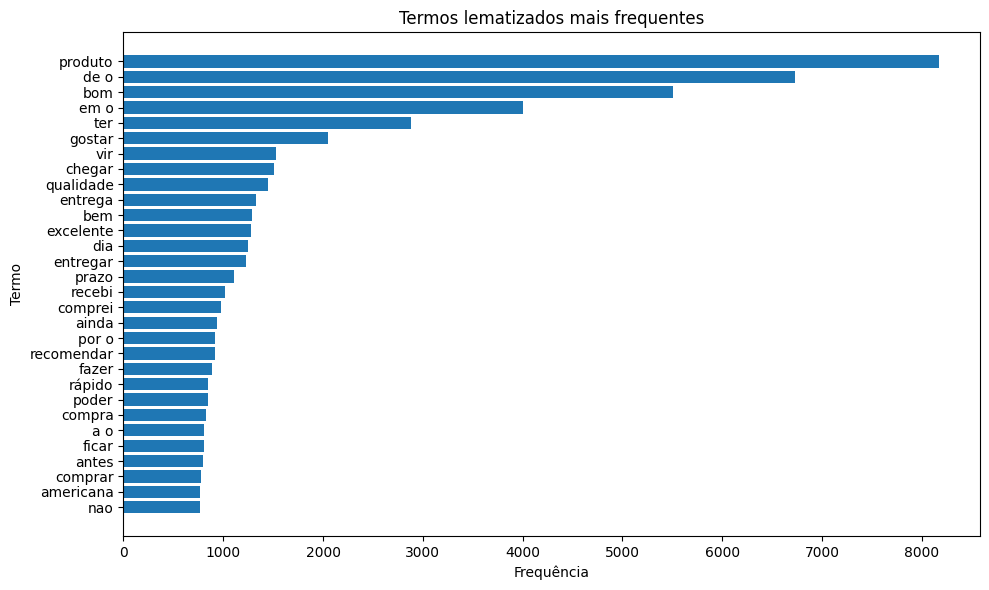

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(top_terms["termo"][::-1], top_terms["frequencia"][::-1])
plt.title("Termos lematizados mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("Termo")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "section_1_top_terms_lemma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

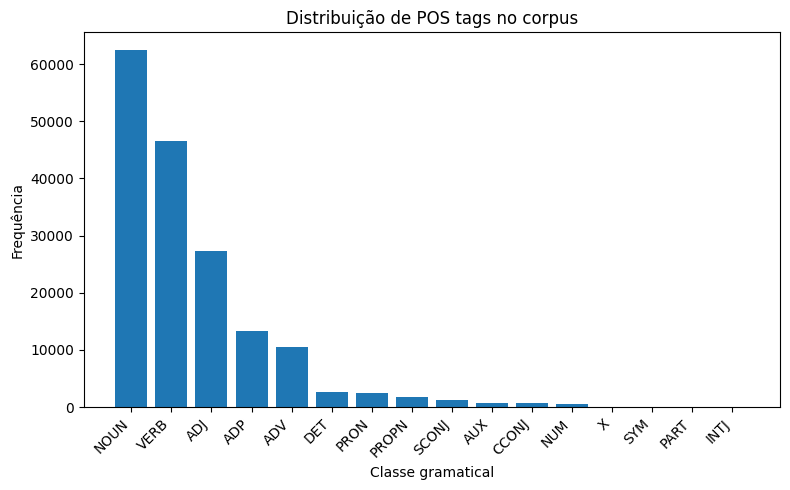

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(pos_counts["pos"], pos_counts["frequencia"])
plt.title("Distribuição de POS tags no corpus")
plt.xlabel("Classe gramatical")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "section_1_pos_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

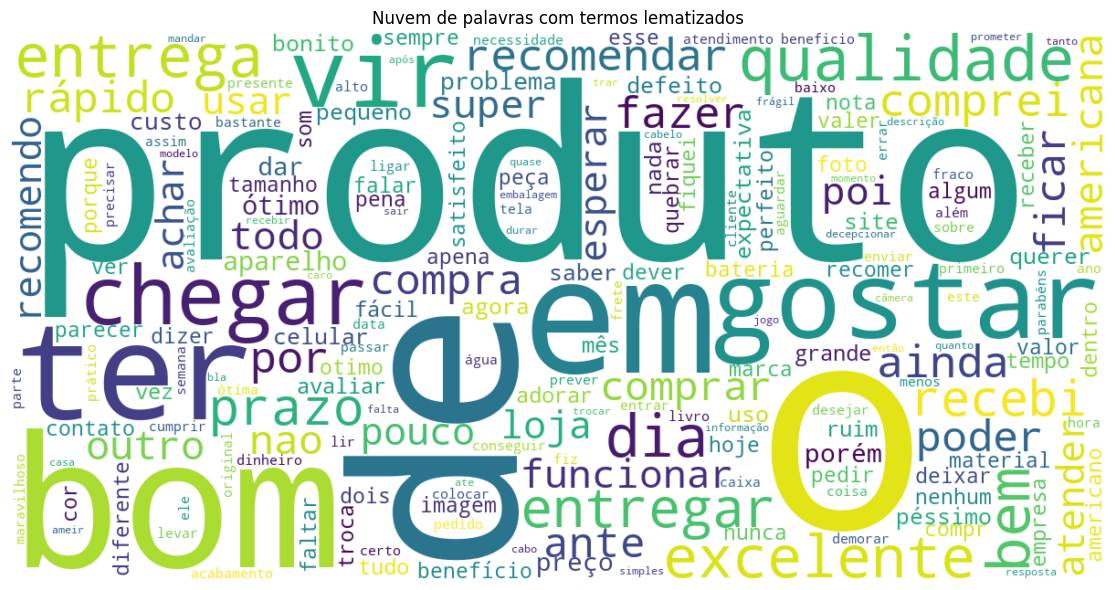

In [32]:
from wordcloud import WordCloud

wordcloud_text = " ".join(df["text_lemma"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(wordcloud_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras com termos lematizados")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "section_1_wordcloud_lemma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.9 Decisão técnica sobre a representação textual

Após a comparação entre stemming e lemmatização, a versão lematizada foi adotada como principal representação textual para as próximas etapas do pipeline, porque a lemmatização preserva melhor a interpretabilidade dos termos em português. Embora o stemming reduza o vocabulário de forma mais agressiva, ele pode gerar radicais artificiais e menos compreensíveis, dificultando a interpretação de tópicos, termos frequentes, resultados de busca textual e relações no grafo de conhecimento. Assim, o stemming foi utilizado como comparação metodológica, enquanto a lemmatização será usada como base principal para representação vetorial, análise de tópicos, classificação e visualizações posteriores.

## 1.10 Salvamento da base pré-processada

A base pré-processada será salva em `data/processed/repro_preprocessed.csv`.

Esse arquivo contém o texto bruto, o texto normalizado, tokens, versão sem stopwords, versão com stemming, versão com lemmatização e informações auxiliares geradas nesta seção.

Nas próximas seções, a coluna principal utilizada será `text_lemma`, pois ela contém a versão textual lematizada e filtrada do corpus.

In [33]:
processed_path = DATA_PROCESSED_DIR / "repro_preprocessed.csv"
pos_path = OUTPUT_TABLES_DIR / "section_1_pos_tokens.csv"

df.to_csv(processed_path, index=False, encoding="utf-8")
pos_df.to_csv(pos_path, index=False, encoding="utf-8")

print("Base pré-processada salva em:")
print(processed_path)

print("\nTabela de tokens com POS tagging salva em:")
print(pos_path)

print("\nArquivos existem?")
print("Base pré-processada:", processed_path.exists())
print("POS tokens:", pos_path.exists())

Base pré-processada salva em:
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\data\processed\repro_preprocessed.csv

Tabela de tokens com POS tagging salva em:
C:\Users\breno\Desktop\Processamento de linguagem natural - Assessment\pln-repro-ecommerce\outputs\tables\section_1_pos_tokens.csv

Arquivos existem?
Base pré-processada: True
POS tokens: True


In [34]:
print("Arquivos gerados na Seção 1:")

section_1_outputs = [
    DATA_PROCESSED_DIR / "repro_preprocessed.csv",
    OUTPUT_TABLES_DIR / "section_1_text_initial_summary.csv",
    OUTPUT_TABLES_DIR / "section_1_vocab_impact.csv",
    OUTPUT_TABLES_DIR / "section_1_pos_distribution.csv",
    OUTPUT_TABLES_DIR / "section_1_top_terms_lemma.csv",
    OUTPUT_TABLES_DIR / "section_1_pos_tokens.csv",
    OUTPUT_FIGURES_DIR / "section_1_vocab_impact.png",
    OUTPUT_FIGURES_DIR / "section_1_document_length_histogram.png",
    OUTPUT_FIGURES_DIR / "section_1_top_terms_lemma.png",
    OUTPUT_FIGURES_DIR / "section_1_pos_distribution.png",
    OUTPUT_FIGURES_DIR / "section_1_wordcloud_lemma.png"
]

for path in section_1_outputs:
    print(path.relative_to(BASE_DIR), "->", path.exists())

Arquivos gerados na Seção 1:
data\processed\repro_preprocessed.csv -> True
outputs\tables\section_1_text_initial_summary.csv -> True
outputs\tables\section_1_vocab_impact.csv -> True
outputs\tables\section_1_pos_distribution.csv -> True
outputs\tables\section_1_top_terms_lemma.csv -> True
outputs\tables\section_1_pos_tokens.csv -> True
outputs\figures\section_1_vocab_impact.png -> True
outputs\figures\section_1_document_length_histogram.png -> True
outputs\figures\section_1_top_terms_lemma.png -> True
outputs\figures\section_1_pos_distribution.png -> True
outputs\figures\section_1_wordcloud_lemma.png -> True


## 1.11 Síntese da Seção 1

Nesta seção foi construído um pipeline de pré-processamento textual aplicado ao corpus real de avaliações de e-commerce.

O corpus foi carregado a partir da base intermediária, inspecionado e submetido a tokenização de sentenças e palavras. Em seguida, os textos foram normalizados, removendo URLs, e-mails, caracteres não alfabéticos e espaços duplicados, preservando acentos por se tratar de um corpus em português.

A remoção de stopwords combinou a lista padrão do NLTK com termos customizados comuns em linguagem informal, termos importantes do domínio foram preservados para não prejudicar análises posteriores.

A comparação entre stemming e lemmatização mostrou o impacto dessas estratégias sobre o vocabulário. O stemming reduz mais agressivamente os termos, mas compromete a interpretabilidade, já a lemmatização, por preservar formas linguísticas mais compreensíveis, foi escolhida como representação principal para as próximas etapas.

Também foi aplicado POS tagging com spaCy, permitindo caracterizar o corpus de acordo com classes gramaticais. As visualizações geradas nesta seção incluem histograma de comprimento dos documentos, distribuição dos termos frequentes, distribuição de POS tags, análise do tamanho do vocabulário e nuvem de palavras.